# Phase I Plotting

This notebook is intentionally kept separate from `main_solver.py`, `utils.py`, and `req_functions.py`. It runs `main_solver.py` so the contour and residual plots are produced with the exact same plotting commands and filenames used by the main solver.

In [5]:
from pathlib import Path
import os
import shutil

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display

# Run from the folder containing main_solver.py.
if Path.cwd().name != 'start-code' and (Path.cwd() / 'start-code').exists():
    os.chdir(Path.cwd() / 'start-code')

plot_dir = Path('Phase I Plots')
plot_dir.mkdir(exist_ok=True)

print(f'Working directory: {Path.cwd()}')
print(f'Plot output directory: {plot_dir.resolve()}')

Working directory: /Users/windy/mae4100-courseproject2/start-code
Plot output directory: /Users/windy/mae4100-courseproject2/start-code/Phase I Plots


/Users/windy/mae4100-courseproject2/start-code/req_functions.py:77: SyntaxWarning: invalid escape sequence '\l'
  """


Iter.    Time (s)   dt (s)      Continuity    x-Momentum    y-Momentum
0   9.765625e-04   9.765625e-04   1.000000e+00   1.000000e+00   1.000000e+00
199   1.953125e-01   9.765625e-04   1.019877e-04   8.058646e-07   5.719258e-04
399   3.906250e-01   9.765625e-04   1.181315e-07   4.698803e-10   2.707759e-07
599   5.859375e-01   9.765625e-04   2.320590e-10   6.446902e-13   5.006747e-10
651 6.367188e-01 4.626943e-11 1.240270e-13 9.913961e-11
Elapsed time is  0.4093949794769287 sec
[0. 0. 0.] [0. 0. 0.] [0. 0. 0.]


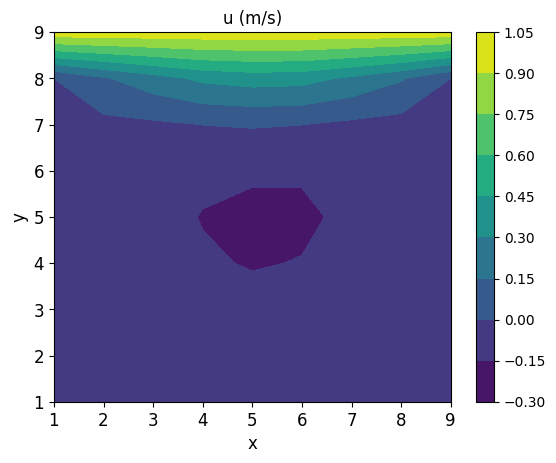

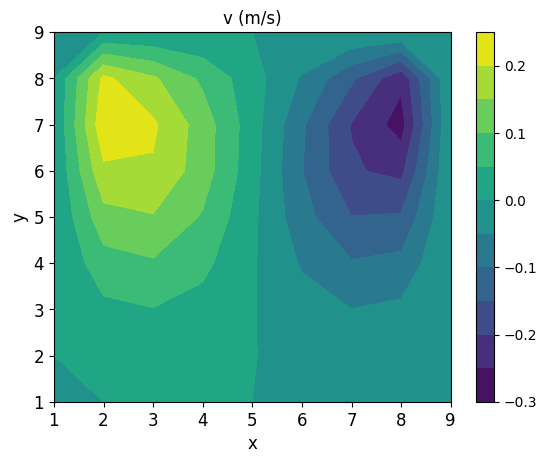

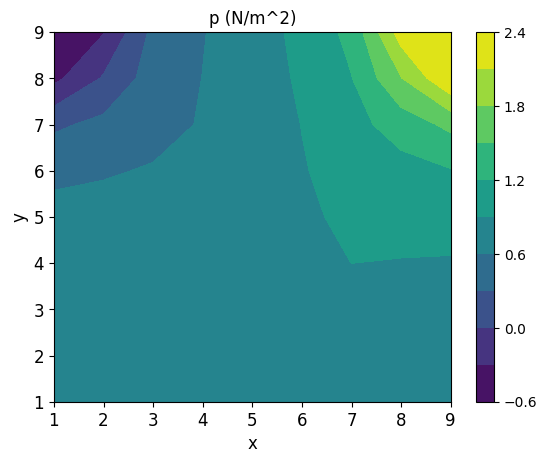

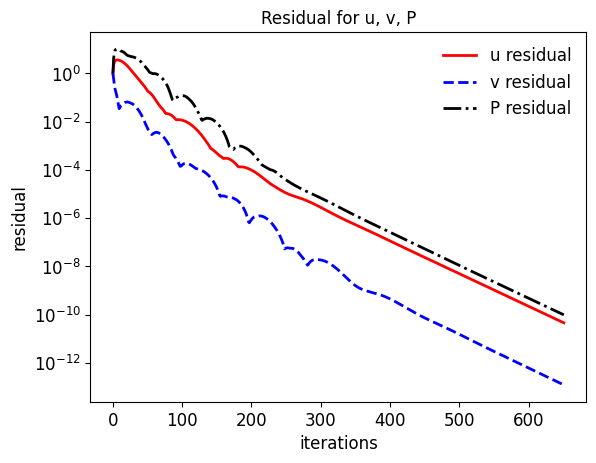

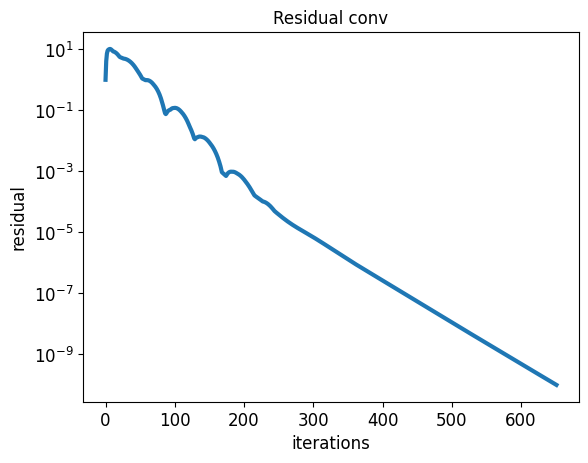

In [2]:
# This preserves the plotting behavior from main_solver.py exactly.
%run -i main_solver.py

main_plot_files = [
    'ucontour.png',
    'vcontour.png',
    'pcontour.png',
    'residualcomponent.png',
    'residual.png',
]

for filename in main_plot_files:
    src = Path(filename)
    if src.exists():
        shutil.move(str(src), str(plot_dir / filename))

Phase I Plots/ucontour.png


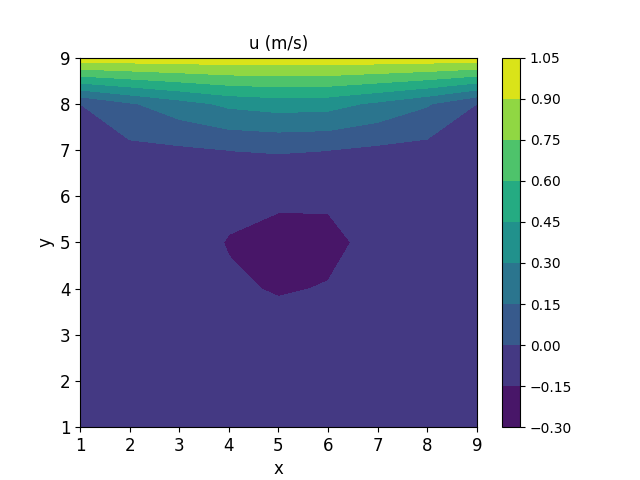

Phase I Plots/vcontour.png


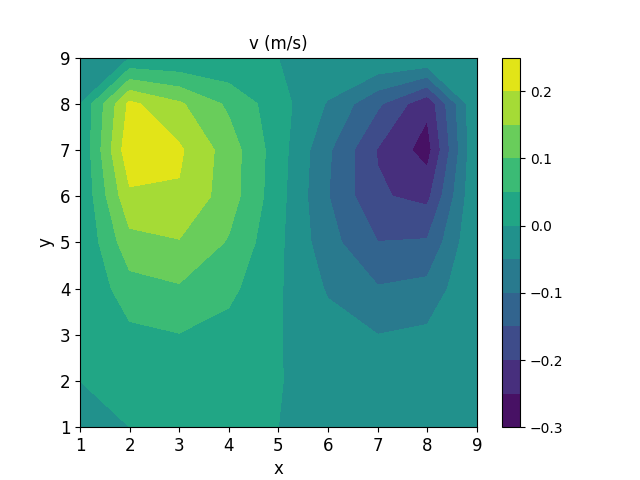

Phase I Plots/pcontour.png


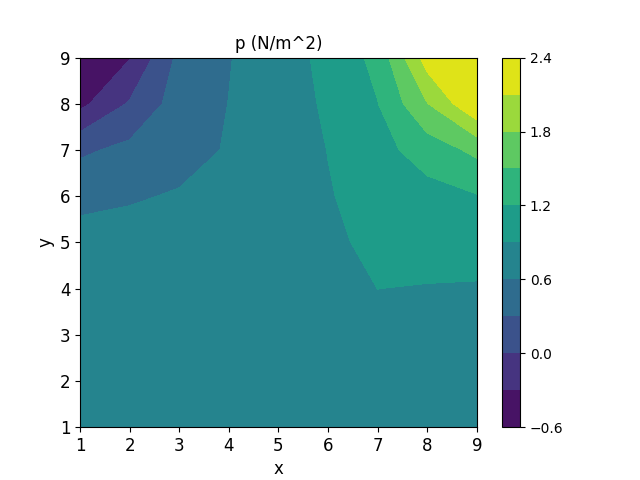

Phase I Plots/residualcomponent.png


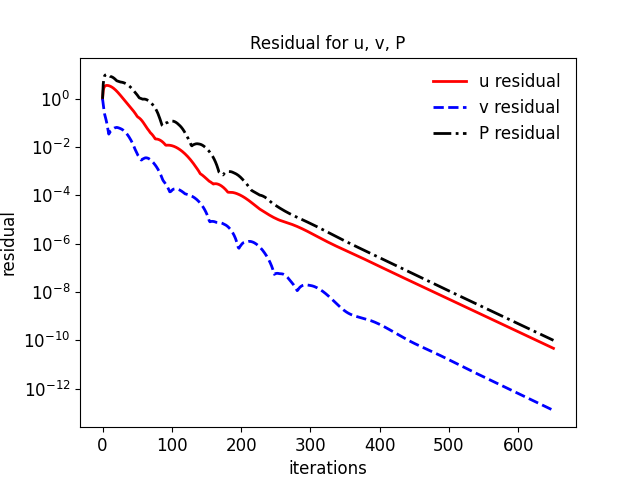

Phase I Plots/residual.png


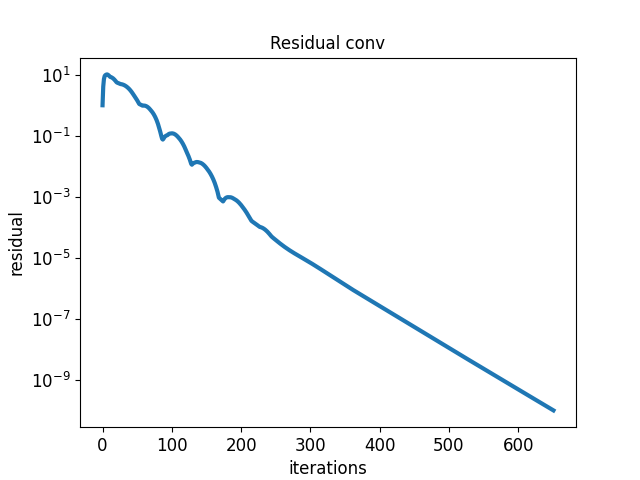

In [3]:
for filename in main_plot_files:
    path = plot_dir / filename
    if path.exists():
        print(path)
        display(Image(filename=str(path)))
    else:
        print(f'Missing expected plot: {path}')

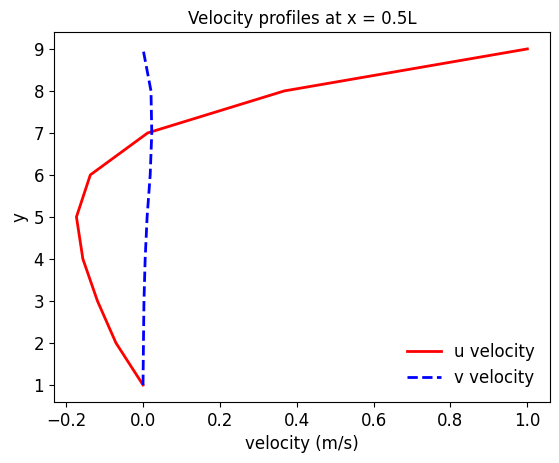

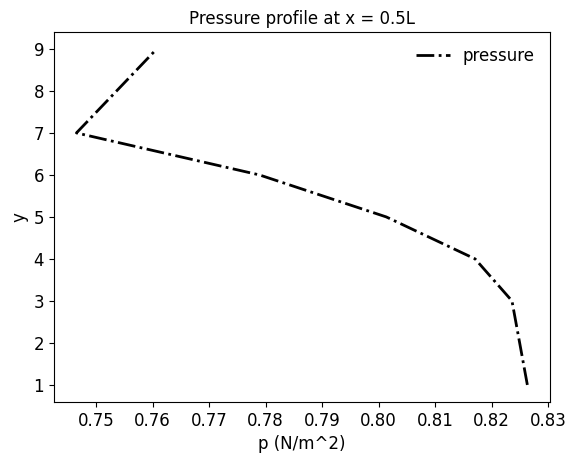

In [4]:
fontsize = 12
i_mid = (imax - 1) // 2
y_profile = np.arange(1, jmax + 1)

plt.figure(6)
plt.plot(u[i_mid, :, 1], y_profile, '-r', linewidth=2, label='u velocity')
plt.plot(u[i_mid, :, 2], y_profile, '--b', linewidth=2, label='v velocity')
plt.xlabel('velocity (m/s)', fontsize=fontsize)
plt.ylabel('y', fontsize=fontsize)
plt.title('Velocity profiles at x = 0.5L', fontsize=fontsize)
plt.legend(loc='best', fontsize=fontsize, frameon=False)
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.savefig(plot_dir / 'velocity_centerline_profiles.png')
plt.show()

plt.figure(7)
plt.plot(u[i_mid, :, 0], y_profile, '-.k', linewidth=2, label='pressure')
plt.xlabel('p (N/m^2)', fontsize=fontsize)
plt.ylabel('y', fontsize=fontsize)
plt.title('Pressure profile at x = 0.5L', fontsize=fontsize)
plt.legend(loc='best', fontsize=fontsize, frameon=False)
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.savefig(plot_dir / 'pressure_centerline_profile.png')
plt.show()